In [12]:
# Основные библиотеки
import numpy as np
import pandas as pd
import os
#import pyarrow.parquet as pq

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Разбиение данных на тренировочные и тестовые
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA

# Алгоритмы
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from tensorflow import keras
# from tensorflow.keras.layers import Dense, Flatten, Dropout

# Метрики$
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import log_loss

def precision( y, y_pred, y_proba, shold, label ):
    ind_f = ( y==label ) & ( y_pred!=label ) & ( y_proba[:,label]<shold )   # errors     
    ind_p = ( y_pred==label ) & ( y==label ) & ( y_proba[:,label]>=shold )  # rights
    return( y[ind_p].shape[0]/(y[ind_p].shape[0] + y[ind_f].shape[0] ) )

def recall( y, y_pred, y_proba, shold, label1, label2 ):
    ind_f = ( y==label2 ) & ( y_pred!=label2 )# & ( y_proba[:,label1]<shold )   # errors FN    
    ind_p = ( y_pred==label1 ) & ( y==label1 ) # & ( y_proba[:,label]>=shold )  # rights  TP
    return( y[ind_p].shape[0]/(y[ind_p].shape[0] + y[ind_f].shape[0] ) )

def accuracy (y, y_pred, y_proba, shold, label_pos, label_neg):
    accuracy = np.where( y==y_pred )[0].shape[0]/y.shape[0]
    return ( accuracy )
    
def f1_score (y, y_pred, y_proba, shold, label_pos, label_neg):
    p = precision(y, y_pred, y_proba, shold, label_pos)
    r = recall(y, y_pred, y_proba, shold, label_pos, label_neg)
    return 2 * ( ( p * r )/( p + r ) )

In [2]:
import sklearn, numpy
print(sklearn.__version__)
print(numpy.__version__)
!pip install -U numpy # Обновление библиотеки - !pip install -U ...
#!pip install -U scikit-learn

1.3.2
1.24.4
Defaulting to user installation because normal site-packages is not writeable


In [13]:
file_csv_all_25 = '2_data_csv_all_25.csv' # Загрузка данных только с 25 признаками с целью сохранения оперативной памяти
df = pd.read_csv(file_csv_all_25)
columns_pay_25 = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
                  'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 
                  'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 
                  'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 
                  'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 
                  'enc_paym_15', 'enc_paym_16', 'enc_paym_17', 
                  'enc_paym_18', 'enc_paym_19', 'enc_paym_20',
                  'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24'] # 25 признаков
columns_pay_19 = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
                  'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 
                  'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 
                  'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 
                  'enc_paym_12', 'enc_paym_13', 'enc_paym_14', 
                  'enc_paym_15', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24']
X_pay_19 = df.loc[:, columns_pay_19].copy()
X_pay_25 = df.loc[:, columns_pay_25].copy() 

In [14]:
df_y = pd.read_csv('train_target.csv')
y  = df_y.flag.values[:] # Глава 2. 1 млн клиентов до аномальности
y_ = df_y.flag.values[:] # Глава 2. 1 млн клиентов после аномальности

In [15]:
df = df.reset_index(drop=True)
df_y = df_y.reset_index(drop=True)

df['id'] = df.index
df_y['id'] = df_y.index

random = X_pay_19.index.to_series().sample(n=100000, random_state=42).values
y_ = df_y.loc[random, 'flag'].to_numpy().copy()

In [16]:
X_pay_19 = X_pay_19.loc[random].copy()
X_pay_25 = X_pay_25.loc[random].copy() 

# Аномальность на 25 признаках

In [17]:
counter_norm, counter_anom = 0, 0
ind_norm, ind_anom = [], []
for i,x_pay in enumerate(np.array(X_pay_25)):
    if y_[i]==0 and min(x_pay)>0:
        counter_anom +=1
        ind_anom.append( i )
        y_[i]=1
    else:
        counter_norm +=1
        ind_norm.append( i )
        
print(f'amount of anomal customer={counter_anom}')
print(f'amount of normal customer={counter_norm}') 

amount of anomal customer=32695
amount of normal customer=67305


# Splitting

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split( X_pay_19, y_, test_size=0.25, random_state=0 )

In [4]:
# columns_pay = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
#                'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 'enc_paym_6', 'enc_paym_7',
#                'enc_paym_8', 'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 'enc_paym_12',
#                'enc_paym_13', 'enc_paym_14', 'enc_paym_15', 'enc_paym_16',
#                'enc_paym_17', 'enc_paym_18', 'enc_paym_19', 'enc_paym_20',
#                'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24']
# columns_pay = ['enc_paym_0', 'enc_paym_1', 'enc_paym_2',
#                'enc_paym_3', 'enc_paym_4', 'enc_paym_5', 'enc_paym_6', 'enc_paym_7',
#                'enc_paym_8', 'enc_paym_9', 'enc_paym_10', 'enc_paym_11', 'enc_paym_12',
#                'enc_paym_13', 'enc_paym_14', 'enc_paym_15', 
#                'enc_paym_22', 'enc_paym_23', 'enc_paym_24']

#X_pay = df.loc[:1000000, columns_pay].copy() # Дисциплинарная матрица
#X_pay = df.loc[:, columns_pay].copy() # Дисциплинарная матрица
#X_pay = X_pay.loc[:10000,:]

In [17]:
df = df.reset_index(drop=True)
df['id'] = df.index

df_y = df_y.reset_index(drop=True)
df_y['id'] = df_y.index
df_y = df_y.set_index('id')

df_ = df['id'].sample(n=100_000, random_state=42) 

X_ = df.loc[df_.values, columns_pay_19].copy() 
y_ = df_y.loc[df_.values, 'flag'].to_numpy()

In [14]:
df_y = pd.read_csv('train_target.csv')
y_ = df_y.flag.values[:1000001] 
y  = df_y.flag.values[:1000001]
# y_ = df_y.flag.values 
# y  = df_y.flag.values

In [5]:
# counter_norm, counter_anom = 0, 0
# ind_norm, ind_anom = [], []
# for i,x_pay in enumerate(np.array(X_pay)):
#     if y_[i]==0 and min(x_pay)>0:
#         counter_anom +=1
#         ind_anom.append( i )
#         y_[i]=1
#     else:
#         counter_norm +=1
#         ind_norm.append( i )
        
# print(f'amount of anomal customer={counter_anom}')
# print(f'amount of normal customer={counter_norm}') 

amount of anomal customer=976475
amount of normal customer=2023525


# Деревья решений
# Вариант 1

In [7]:
dtree = DecisionTreeClassifier()
dtree.fit( X_train, Y_train )

DecisionTreeClassifier()

In [8]:
# param_space = {
#     'criterion': ['gini', 'entropy', 'log_loss'],
#     'splitter':  ['best', 'random'],
#     'max_depth': [15, 20, 25, 30, 40, 50, 60, 70, 80],
#     'min_samples_split': [ 10, 15, 20, 25, 30, 40, 50, 60, 70, 80],
#     'min_samples_leaf': [5, 10, 15, 20, 25, 30, 40 , 50, 60, 70, 80],
#     'max_features': ['sqrt', 'log2']
#     #'random_state': [42]
# }
param_space = {
    'criterion': [ 'entropy', 'log_loss' ],
    'splitter':  ['best', 'random'],
    'max_depth': [15, 20, 25, 30],
    'min_samples_split': [10, 15, 20, 25, 30],
    'min_samples_leaf': [5, 10, 15, 20, 25, 30],
    'max_features': ['sqrt', 'log2']
}

In [10]:
grid_dtree = RandomizedSearchCV( dtree, param_space )  # Parameter selection
grid_dtree.fit( X_train, Y_train.ravel() )       # Model training with hyperparameter selection
print( grid_dtree.best_estimator_ )              # Output of the best found parameters

DecisionTreeClassifier(criterion='entropy', max_depth=25, max_features='log2',
                       min_samples_leaf=10, min_samples_split=10)


In [9]:
grid_dtree = GridSearchCV( dtree, param_space )  # Parameter selection
grid_dtree.fit( X_train, Y_train.ravel() )       # Model training with hyperparameter selection
print( grid_dtree.best_estimator_ )              # Output of the best found parameters

DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='log2',
                       min_samples_leaf=15, min_samples_split=15)


# GridSearchCV

In [19]:
dtree = DecisionTreeClassifier(criterion='entropy',  # ['gini', 'entropy', 'log_loss']
                               max_depth=20, 
                               max_features='sqrt',
                               min_samples_leaf=20, 
                               min_samples_split=10,
                               random_state=42)
dtree.fit( X_train, Y_train ) 
dtree.score( X_train, Y_train ), dtree.score( X_test, Y_test )

(0.9813453333333333, 0.9807720769116923)

In [20]:
y_pred_train = dtree.predict( X_train )
y_proba_train = dtree.predict_proba( X_train )
y_pred_test = dtree.predict( X_test )
y_proba_test = dtree.predict_proba( X_test )

y_pred_test = dtree.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    469239
           1       1.00      0.95      0.97    280761

    accuracy                           0.98    750000
   macro avg       0.99      0.98      0.98    750000
weighted avg       0.98      0.98      0.98    750000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    156325
           1       1.00      0.95      0.97     93676

    accuracy                           0.98    250001
   macro avg       0.98      0.97      0.98    250001
weighted avg       0.98      0.98      0.98    250001



# Матрица ошибок, ROC_AUC

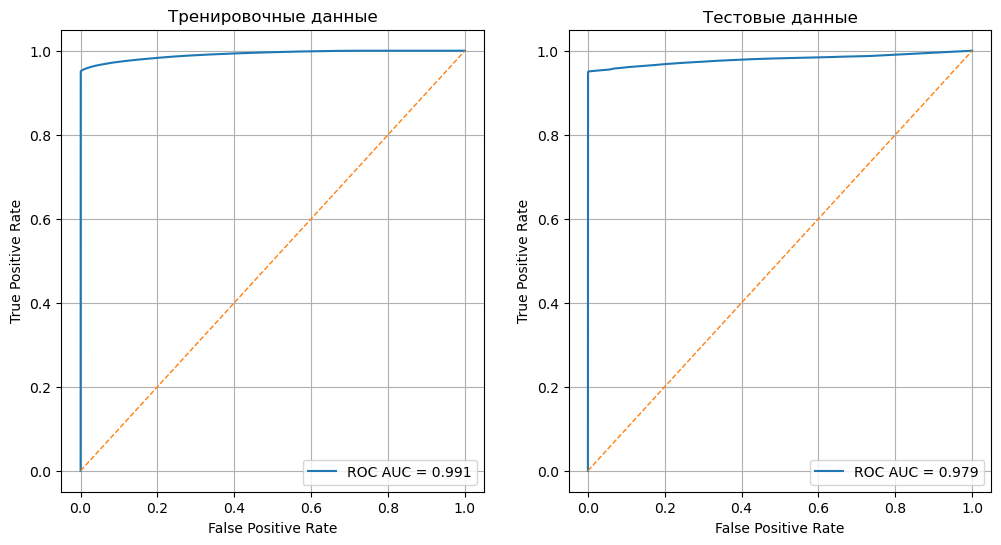

In [21]:
y_score = dtree.predict_proba(X_train)[:, 1]   
fpr, tpr, thr = roc_curve(Y_train, y_score)
auc = roc_auc_score(Y_train, y_score)

fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

ax1.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], '--', linewidth=1) 
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Тренировочные данные')
ax1.legend(loc='lower right')
ax1.grid(True)

y_score = dtree.predict_proba(X_test)[:, 1]   
fpr, tpr, thr = roc_curve(Y_test, y_score)
auc = roc_auc_score(Y_test, y_score)

ax2.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], '--', linewidth=1) 
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Тестовые данные')
ax2.legend(loc='lower right')
ax2.grid(True)

fig.savefig('ROC_AUC_DT_train_test_dtr_big.png', bbox_inches='tight')

[[468936    303]
 [ 13688 267073]]
[[156195    130]
 [  4677  88999]]


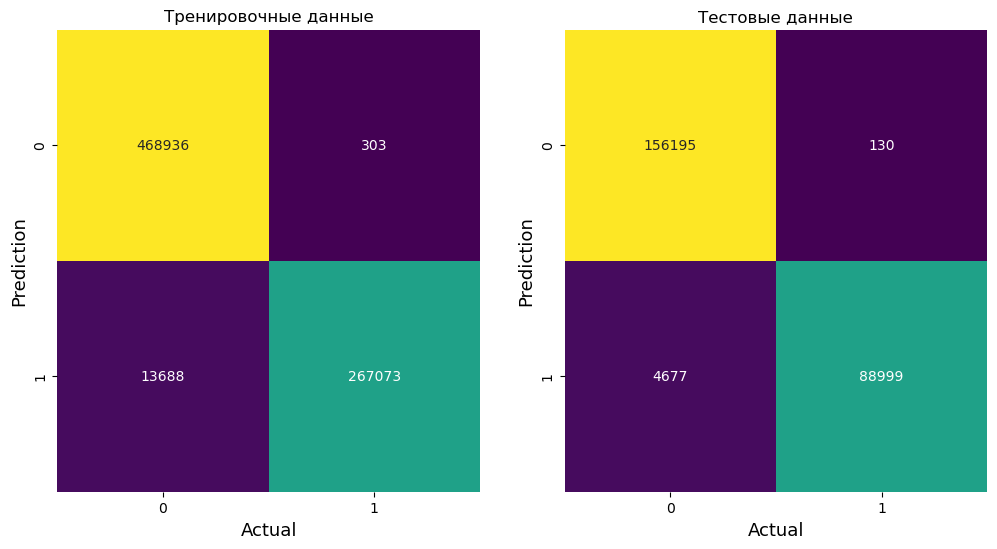

In [22]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = dtree.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            
# disp = ConfusionMatrixDisplay( confusion_matrix = cm,                           
#                                display_labels = ['NO DEFAULT \n 0','DEFAULT \n 1']
#                              )
# disp.plot(ax=ax1)
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Prediction',fontsize = 13)                                           
ax1.set_xlabel('Actual',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = dtree.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            
# disp = ConfusionMatrixDisplay( confusion_matrix = cm,                           
#                                display_labels = ['NO DEFAULT \n 0','DEFAULT \n 1']
#                              )
# disp.plot(ax=ax2)
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Prediction',fontsize = 13)                                           
ax2.set_xlabel('Actual',fontsize = 13)
ax2.set_title('Тестовые данные')

fig.savefig('matrix_dtr_train_test_big.png', bbox_inches='tight')

# GS  ver 2

In [12]:
dtree = DecisionTreeClassifier(criterion='log_loss', 
                               max_depth=25, 
                               max_features='sqrt',
                               min_samples_leaf=15, 
                               min_samples_split=30,
                               random_state=42)
dtree.fit( X_train, Y_train ) 
dtree.score( X_train, Y_train ), dtree.score( X_test, Y_test )

(0.9815186666666667, 0.9810720757116972)

In [13]:
y_pred_train = dtree.predict( X_train )
y_proba_train = dtree.predict_proba( X_train )
y_pred_test = dtree.predict( X_test )
y_proba_test = dtree.predict_proba( X_test )

y_pred_test = dtree.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    469239
           1       1.00      0.95      0.97    280761

    accuracy                           0.98    750000
   macro avg       0.99      0.98      0.98    750000
weighted avg       0.98      0.98      0.98    750000

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    156325
           1       1.00      0.95      0.97     93676

    accuracy                           0.98    250001
   macro avg       0.99      0.97      0.98    250001
weighted avg       0.98      0.98      0.98    250001



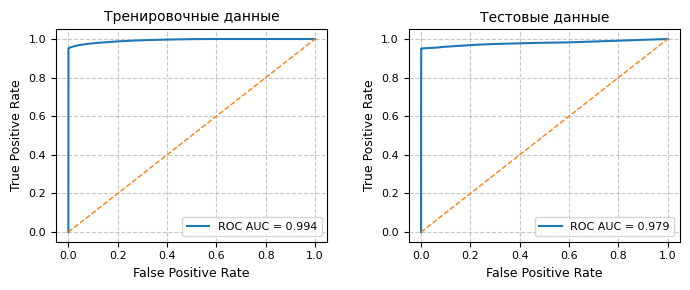

In [17]:
y_score_train = dtree.predict_proba(X_train)[:, 1]   
y_score_test = dtree.predict_proba(X_test)[:, 1] 

fpr_train, tpr_train, thr_train = roc_curve(Y_train, y_score_train)
fpr_test, tpr_test, thr_test = roc_curve(Y_test, y_score_test)

auc_train = roc_auc_score(Y_train, y_score_train)
auc_test = roc_auc_score(Y_test, y_score_test)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), dpi=100)


axes[0].plot(fpr_train, tpr_train, label=f'ROC AUC = {auc_train:.3f}')
axes[0].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[0].set_xlabel('False Positive Rate', fontsize=9)
axes[0].set_ylabel('True Positive Rate', fontsize=9)
axes[0].set_title('Тренировочные данные', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].tick_params(axis='both', which='major', labelsize=8)

axes[1].plot(fpr_test, tpr_test, label=f'ROC AUC = {auc_test:.3f}')
axes[1].plot([0, 1], [0, 1], '--', linewidth=1) 
axes[1].set_xlabel('False Positive Rate', fontsize=9)
axes[1].set_ylabel('True Positive Rate', fontsize=9)
axes[1].set_title('Тестовые данные', fontsize=10)
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)

[[469024    215]
 [ 13646 267115]]
[[156253     72]
 [  4660  89016]]


Text(0.5, 1.0, 'Тестовые данные')

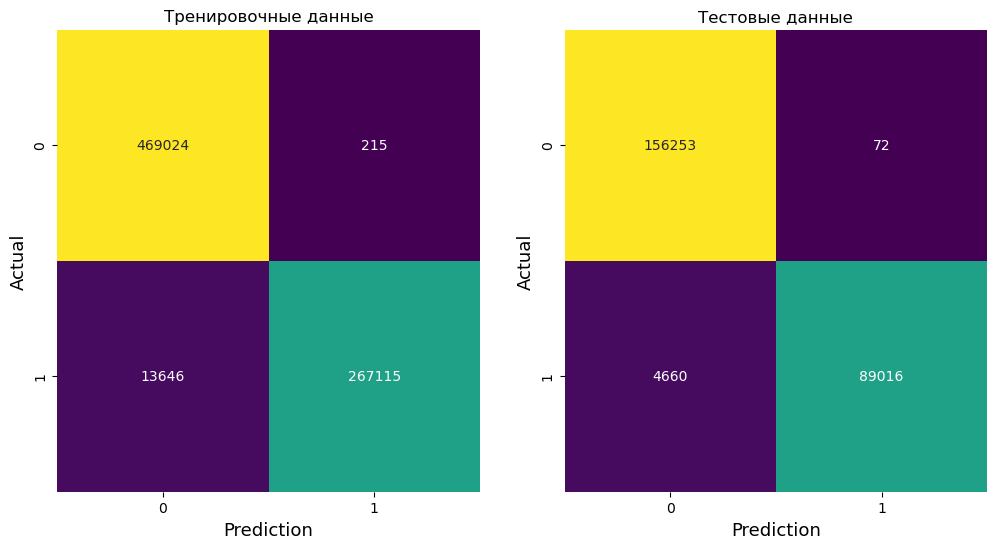

In [18]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = dtree.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Actual',fontsize = 13)                                           
ax1.set_xlabel('Prediction',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = dtree.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            

sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Actual',fontsize = 13)                                           
ax2.set_xlabel('Prediction',fontsize = 13)
ax2.set_title('Тестовые данные')

# RandomizedSearchCV

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split( X_pay, y_, test_size=0.25, random_state=0 )
dtree = DecisionTreeClassifier(criterion='log_loss',
                               #criterion='entropy',
                               max_depth=20, 
                               max_features='sqrt',
                               min_samples_leaf=15, 
                               min_samples_split=15,
                               random_state=42)
dtree.fit( X_train, Y_train ) 
dtree.score( X_train, Y_train ), dtree.score( X_test, Y_test )

(0.9795764444444445, 0.9795386666666667)

In [22]:
y_pred_train = dtree.predict( X_train )
y_proba_train = dtree.predict_proba( X_train )
y_pred_test = dtree.predict( X_test )
y_proba_test = dtree.predict_proba( X_test )

y_pred_test = dtree.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98   1438473
           1       1.00      0.94      0.97    811527

    accuracy                           0.98   2250000
   macro avg       0.98      0.97      0.98   2250000
weighted avg       0.98      0.98      0.98   2250000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    478610
           1       1.00      0.94      0.97    271390

    accuracy                           0.98    750000
   macro avg       0.98      0.97      0.98    750000
weighted avg       0.98      0.98      0.98    750000



# Матрица ошибок, ROC_AUC 

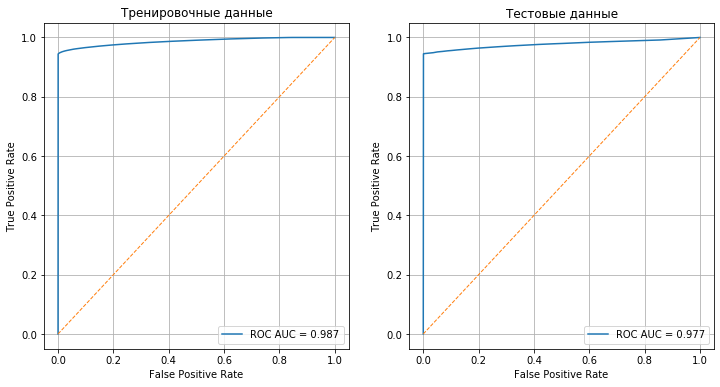

In [23]:
y_score = dtree.predict_proba(X_train)[:, 1]   
fpr, tpr, thr = roc_curve(Y_train, y_score)
auc = roc_auc_score(Y_train, y_score)

fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

ax1.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], '--', linewidth=1) 
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Тренировочные данные')
ax1.legend(loc='lower right')
ax1.grid(True)

y_score = dtree.predict_proba(X_test)[:, 1]   
fpr, tpr, thr = roc_curve(Y_test, y_score)
auc = roc_auc_score(Y_test, y_score)

ax2.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], '--', linewidth=1) 
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Тестовые данные')
ax2.legend(loc='lower right')
ax2.grid(True)

fig.savefig('ROC_AUC_DT_train_test_dtr_big.png', bbox_inches='tight')

[[1437506     967]
 [  44986  766541]]
[[478211    399]
 [ 14947 256443]]


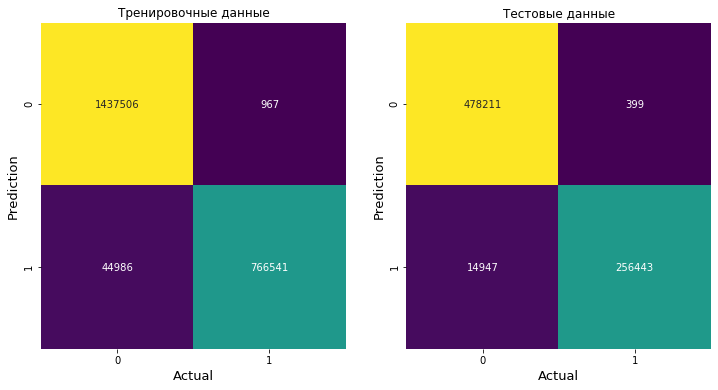

In [24]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = dtree.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            
# disp = ConfusionMatrixDisplay( confusion_matrix = cm,                           
#                                display_labels = ['NO DEFAULT \n 0','DEFAULT \n 1']
#                              )
# disp.plot(ax=ax1)
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Prediction',fontsize = 13)                                           
ax1.set_xlabel('Actual',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = dtree.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            
# disp = ConfusionMatrixDisplay( confusion_matrix = cm,                           
#                                display_labels = ['NO DEFAULT \n 0','DEFAULT \n 1']
#                              )
# disp.plot(ax=ax2)
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Prediction',fontsize = 13)                                           
ax2.set_xlabel('Actual',fontsize = 13)
ax2.set_title('Тестовые данные')

fig.savefig('matrix_dtr_train_test_big.png', bbox_inches='tight')

# Случайный лес

In [19]:
rfc = RandomForestClassifier()
rfc.fit( X_train, Y_train )

RandomForestClassifier()

In [20]:
param_space = {
    'n_estimators': [30, 40, 60],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 20, 30],
    'min_samples_split': [ 10, 20, 30],
    'min_samples_leaf': [10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

# RandomizedSearchCV

In [22]:
grid_rfc = RandomizedSearchCV( rfc, param_space )  # Parameter selection
grid_rfc.fit( X_train, Y_train.ravel() )       # Model training with hyperparameter selection
print( grid_rfc.best_estimator_ )              # Output of the best found parameters

RandomForestClassifier(criterion='entropy', max_depth=30, max_features='log2',
                       min_samples_leaf=10, min_samples_split=10,
                       n_estimators=40)


In [19]:
X_train, X_test, Y_train, Y_test = train_test_split( X_, y_, test_size=0.25, random_state=0 )
rfc = RandomForestClassifier(criterion='log_loss', 
                             max_depth=20, 
                             min_samples_leaf=15,
                             min_samples_split=20,
                             max_features='log2',
                             n_estimators=80, 
                             random_state=42)
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test )

(0.9796933333333333, 0.97872)

In [20]:
# y_pred_train = rfc.predict( X_train )
y_proba_train = rfc.predict_proba( X_train )
y_pred_test = rfc.predict( X_test )
y_proba_test = rfc.predict_proba( X_test )

#y_pred_test = dtree.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     47817
           1       1.00      0.95      0.97     27183

    accuracy                           0.98     75000
   macro avg       0.98      0.97      0.98     75000
weighted avg       0.98      0.98      0.98     75000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     16032
           1       1.00      0.94      0.97      8968

    accuracy                           0.98     25000
   macro avg       0.98      0.97      0.98     25000
weighted avg       0.98      0.98      0.98     25000



# Gridsearch

In [21]:
grid_rfc = GridSearchCV( rfc, param_space )  # Parameter selection
grid_rfc.fit( X_train, Y_train.ravel() )       # Model training with hyperparameter selection
print( grid_rfc.best_estimator_ )              # Output of the best found parameters

RandomForestClassifier(max_depth=20, min_samples_leaf=10, min_samples_split=30,
                       n_estimators=60)


In [13]:
X_train, X_test, Y_train, Y_test = training _test_split( X_, y_, test_size=0.25, random_state=0 )
rfc = RandomForestClassifier(max_depth=20, 
                             min_samples_leaf=10, 
                             min_samples_split=30,
                             n_estimators=60, 
                             random_state=42)
rfc.fit( X_train, Y_train )
rfc.score( X_train, Y_train ), rfc.score( X_test, Y_test )

(0.9800133333333333, 0.97928)

In [14]:
y_pred_train = rfc.predict( X_train )
y_proba_train = rfc.predict_proba( X_train )
y_pred_test = rfc.predict( X_test )
y_proba_test = rfc.predict_proba( X_test )

y_pred_test = rfc.predict( X_test )
print( classification_report(  Y_train, y_pred_train  ) )
print( classification_report(  Y_test,  y_pred_test   ) )

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     47817
           1       1.00      0.95      0.97     27183

    accuracy                           0.98     75000
   macro avg       0.98      0.97      0.98     75000
weighted avg       0.98      0.98      0.98     75000

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     16032
           1       1.00      0.94      0.97      8968

    accuracy                           0.98     25000
   macro avg       0.98      0.97      0.98     25000
weighted avg       0.98      0.98      0.98     25000



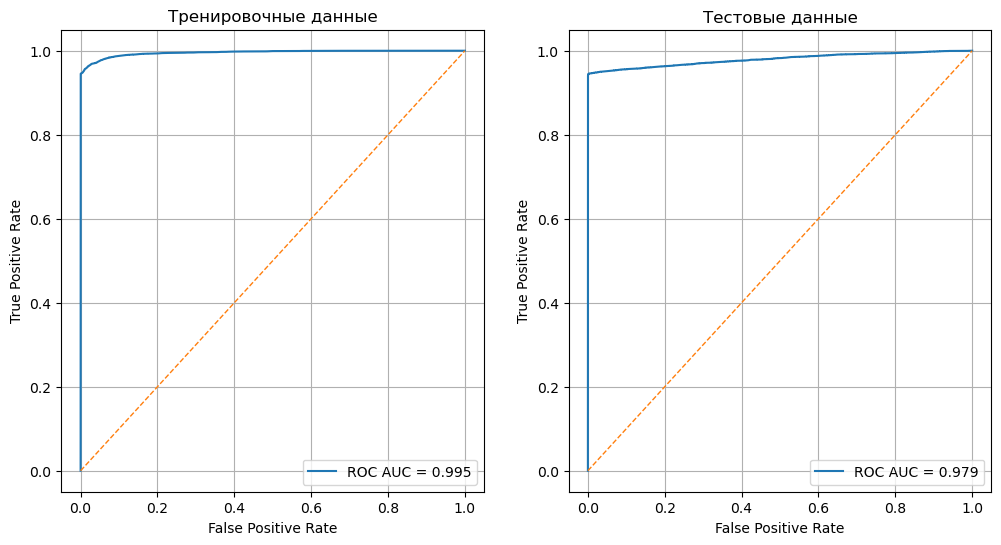

In [15]:
y_score = rfc.predict_proba(X_train)[:, 1]   
fpr, tpr, thr = roc_curve(Y_train, y_score)
auc = roc_auc_score(Y_train, y_score)

fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

ax1.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], '--', linewidth=1) 
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Тренировочные данные')
ax1.legend(loc='lower right')
ax1.grid(True)

y_score = rfc.predict_proba(X_test)[:, 1]   
fpr, tpr, thr = roc_curve(Y_test, y_score)
auc = roc_auc_score(Y_test, y_score)

ax2.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
ax2.plot([0, 1], [0, 1], '--', linewidth=1) 
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Тестовые данные')
ax2.legend(loc='lower right')
ax2.grid(True)

fig.savefig('ROC_AUC_rfc_train_test_dtr_big.png', bbox_inches='tight')

[[47795    22]
 [ 1477 25706]]
[[16013    19]
 [  499  8469]]


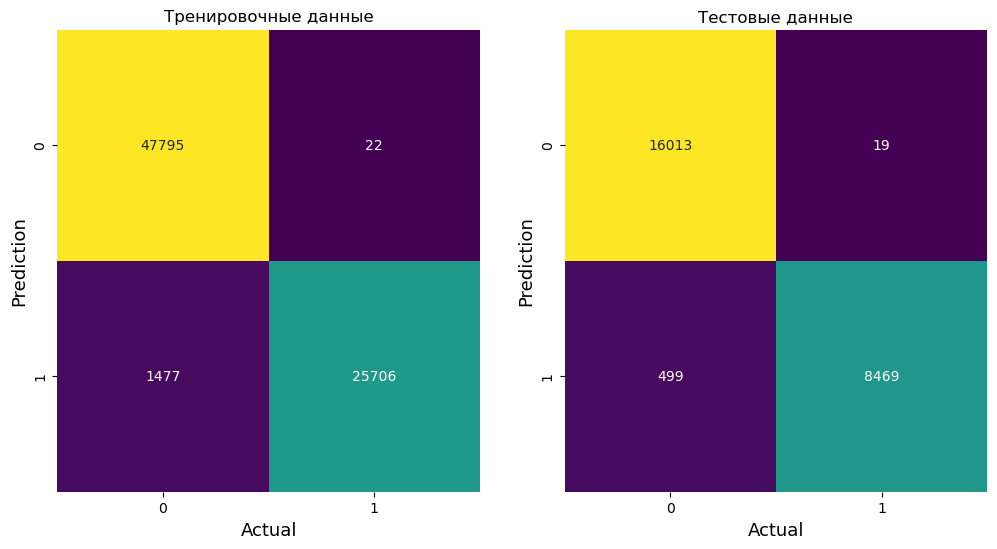

In [16]:
fig, (ax1, ax2) = plt.subplots( nrows = 1, 
                                ncols = 2,
                                figsize=(12,6) )

y_pred_train = rfc.predict(X_train)                                              
cm = confusion_matrix(Y_train, y_pred_train, labels=[0, 1]) 
print( str(cm) )                                                            
# disp = ConfusionMatrixDisplay( confusion_matrix = cm,                           
#                                display_labels = ['NO DEFAULT \n 0','DEFAULT \n 1']
#                              )
# disp.plot(ax=ax1)
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax1)
ax1.set_ylabel('Prediction',fontsize = 13)                                           
ax1.set_xlabel('Actual',fontsize = 13) 
ax1.set_title('Тренировочные данные')

y_pred_test = rfc.predict(X_test)                                              
cm = confusion_matrix(Y_test, y_pred_test, labels=[0, 1]) 
print( str(cm) )                                                            
# disp = ConfusionMatrixDisplay( confusion_matrix = cm,                           
#                                display_labels = ['NO DEFAULT \n 0','DEFAULT \n 1']
#                              )
# disp.plot(ax=ax2)
sns.heatmap(cm, annot=True, fmt='d',  cmap='viridis', cbar=False, ax = ax2)
ax2.set_ylabel('Prediction',fontsize = 13)                                           
ax2.set_xlabel('Actual',fontsize = 13)
ax2.set_title('Тестовые данные')

fig.savefig('matrix_dtr_train_test_big.png', bbox_inches='tight')